In [1]:
from datetime import datetime
from pathlib import Path

import torch
from torch.utils.data import DataLoader

import wandb
import h5py
from pmdd.data import MagnetismData2D
from pmdd.loss import EDMLoss, VPLoss
from pmdd.networks import EDMPrecond, VPPrecond
from pmdd.sample import sample
from pmdd.utils.calc_utils import curl_2d, div_2d
from pmdd.utils.plot_utils import plot_ddpm_sample
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors

In [2]:
cfg = {
    "seed": 0,
    "epochs": 3000,
    "lr": 1e-3,
    "batch_size": 500,
    "dim": 2,
    "res": 64,
    "max": False,
    "db_name": "magfield_symm_64_30000.h5",
    "model_channels" : 16,
    "channel_mult" : [1,2],
    "num_blocks" : 1,
    "data_limit" : None
}

device="cuda:1"

datapath = Path.cwd() / '..' / 'data'
db = MagnetismData2D(datapath, cfg["db_name"], cfg["max"], norm_=False, max_observations=cfg["data_limit"])
fields = h5py.File(datapath / cfg["db_name"])
obs_load = h5py.File(datapath / "magfield_symm_64.h5")
scaling = np.std(fields["field"])

ddpm_chosen = EDMPrecond(cfg["res"], cfg["dim"], model_channels = cfg["model_channels"], 
                  channel_mult = cfg["channel_mult"], num_blocks = cfg["num_blocks"]).to(device)

In [3]:
params_path = Path.cwd() / '..' / 'params'
ddpm_chosen.load_state_dict(torch.load(params_path / "ddpm_layers_2_blocks_1_epoch_3000.pth", weights_only=True))

<All keys matched successfully>

In [4]:
def MAPE(gts, preds, mask=None):
    err = abs(gts - preds)
    if mask==None:
        return torch.mean(err/abs(gts))*100
    else:
        return torch.mean((err/abs(gts))[:,mask[0]==1])*100

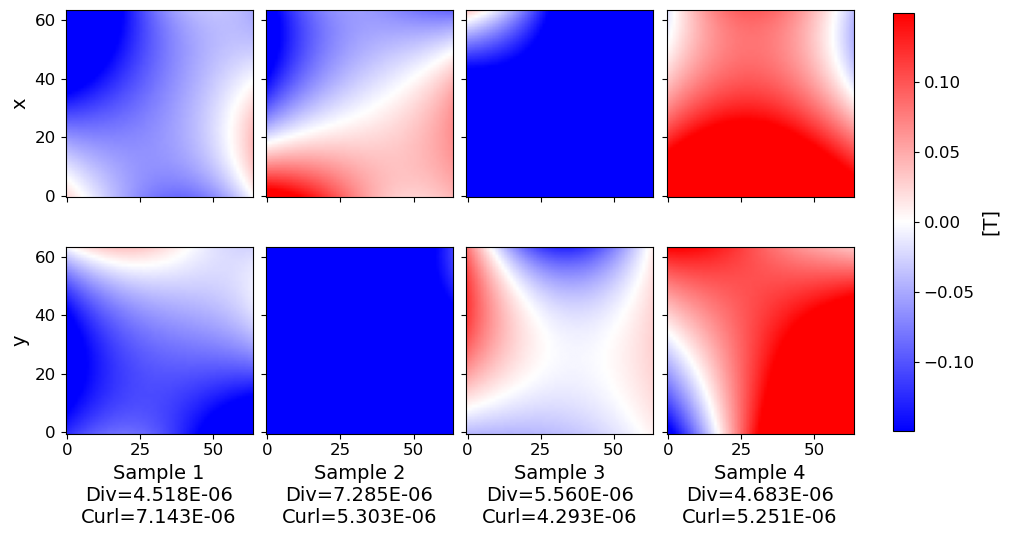

In [5]:
rows = 2
cols = 4
fig, axes = plt.subplots(nrows=rows, ncols=cols, sharex=True, sharey=True, figsize=(10, 5.5), layout="constrained")
vmax=scaling
norm = colors.Normalize(vmin=-vmax, vmax=vmax)
for j, sam in enumerate(fields["field"][0:4]):
        ax1 = axes.flat[j]
        ax2 = axes.flat[j + cols]
        if j==0:
                ax1.set_ylabel("x", fontsize=14)
                ax2.set_ylabel("y", fontsize=14)
        ax2.set_xlabel(f"Sample {j+1}\nDiv={np.abs(curl_2d(sam)).mean():.3E}\nCurl={np.abs(div_2d(sam)).mean():.3E}", fontsize = 14)
        ax1.tick_params(labelsize=12)
        ax2.tick_params(labelsize=12)
        im = ax1.imshow(sam[0], cmap="bwr", norm=norm, origin="lower")
        im = ax2.imshow((sam[1]), cmap="bwr", norm=norm, origin="lower")
#cbar_ax = fig.add_axes([0.93, 0.12, 0.015, 0.75])
cbar1 = fig.colorbar(im, ax=axes, shrink=0.9) #cax=cbar_ax)
cbar1.ax.tick_params(labelsize=12)
cbar1.set_label("[T]", fontsize=14)

In [12]:
n_samples = 1
xh, samples = sample(ddpm_chosen, n_samples, device, num_steps=200, sigma=[0.002, 80], rho=7)

Generating 1 samples...


100%|██████████| 200/200 [00:01<00:00, 141.65step/s]


In [15]:
xh = xh.cpu().detach()
samples = torch.cat([s.cpu().detach() for s in samples])

Text(0.02, 0.5, 'y coordinate [pixel]')

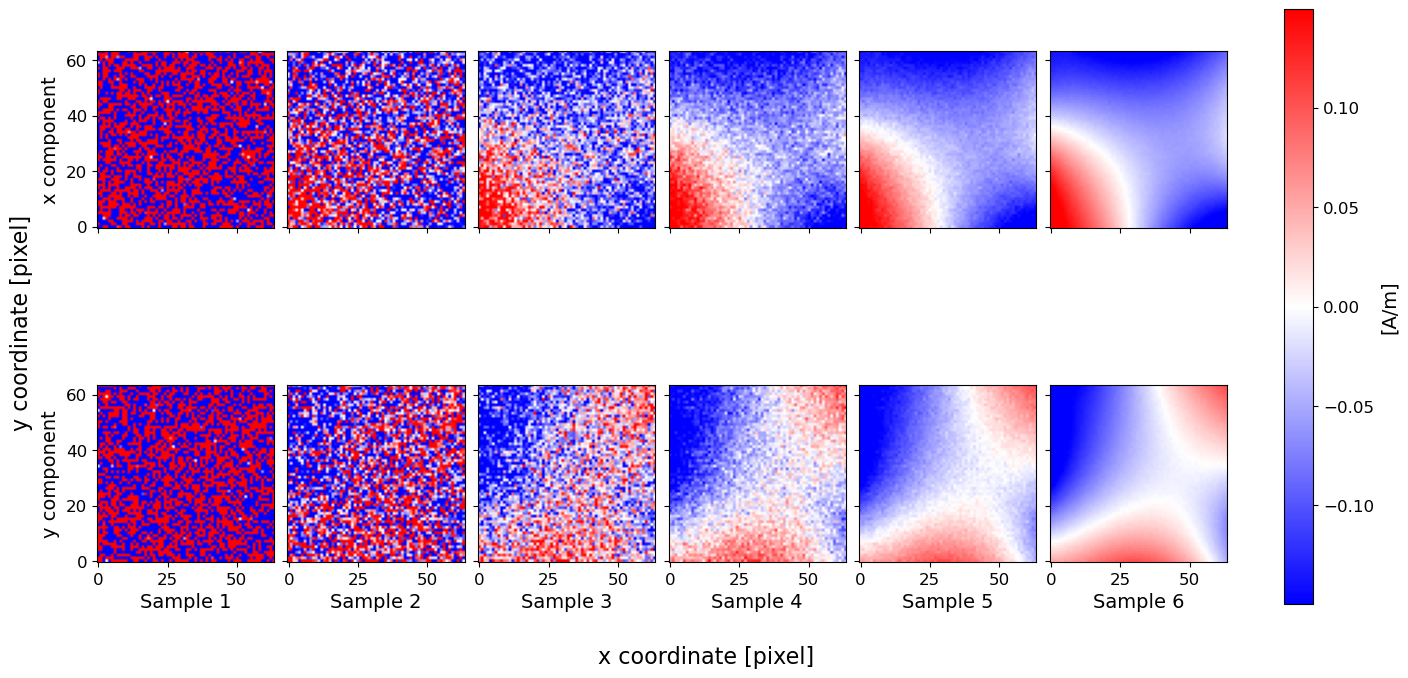

In [26]:
rows = 2
cols = 6
fig, axes = plt.subplots(nrows=rows, ncols=cols, sharex=True, sharey=True, figsize=(14, 7), layout="constrained")
vmax=scaling
norm = colors.Normalize(vmin=-vmax, vmax=vmax)
for j, sam in enumerate([samples[0], samples[11], samples[13], samples[15], samples[17], samples[19]]):
        ax1 = axes.flat[j]
        ax2 = axes.flat[j + cols]
        if j==0:
                ax1.set_ylabel("x component", fontsize=14)
                ax2.set_ylabel("y component", fontsize=14)
        ax2.set_xlabel(f"Sample {j+1}", fontsize = 14)
        ax1.tick_params(labelsize=12)
        ax2.tick_params(labelsize=12)
        im = ax1.imshow(sam[0]*scaling, cmap="bwr", norm=norm, origin="lower")
        im = ax2.imshow(sam[1]*scaling, cmap="bwr", norm=norm, origin="lower")
#cbar_ax = fig.add_axes([0.93, 0.12, 0.015, 0.75])
cbar = fig.colorbar(im, ax=axes, shrink=0.9) #cax=cbar_ax)
cbar.ax.tick_params(labelsize=12)
cbar.set_label("[A/m]", fontsize=14)
fig.supxlabel("x coordinate [pixel]", fontsize=16)
fig.supylabel("y coordinate [pixel]", fontsize=16)


In [8]:
curl_total = 0
div_total = 0
for sam in fields["field"]:
        curl_total += np.abs(curl_2d(sam)).mean()
        div_total += np.abs(div_2d(sam)).mean()

In [9]:
print(curl_total/fields["field"].shape[0])
print(div_total/fields["field"].shape[0])

4.4733515e-06
4.468557e-06


torch.Size([2, 2, 64, 64])
Avg Curl: 0.0010053269298428535 | Avg Div: 0.0010477121528884225


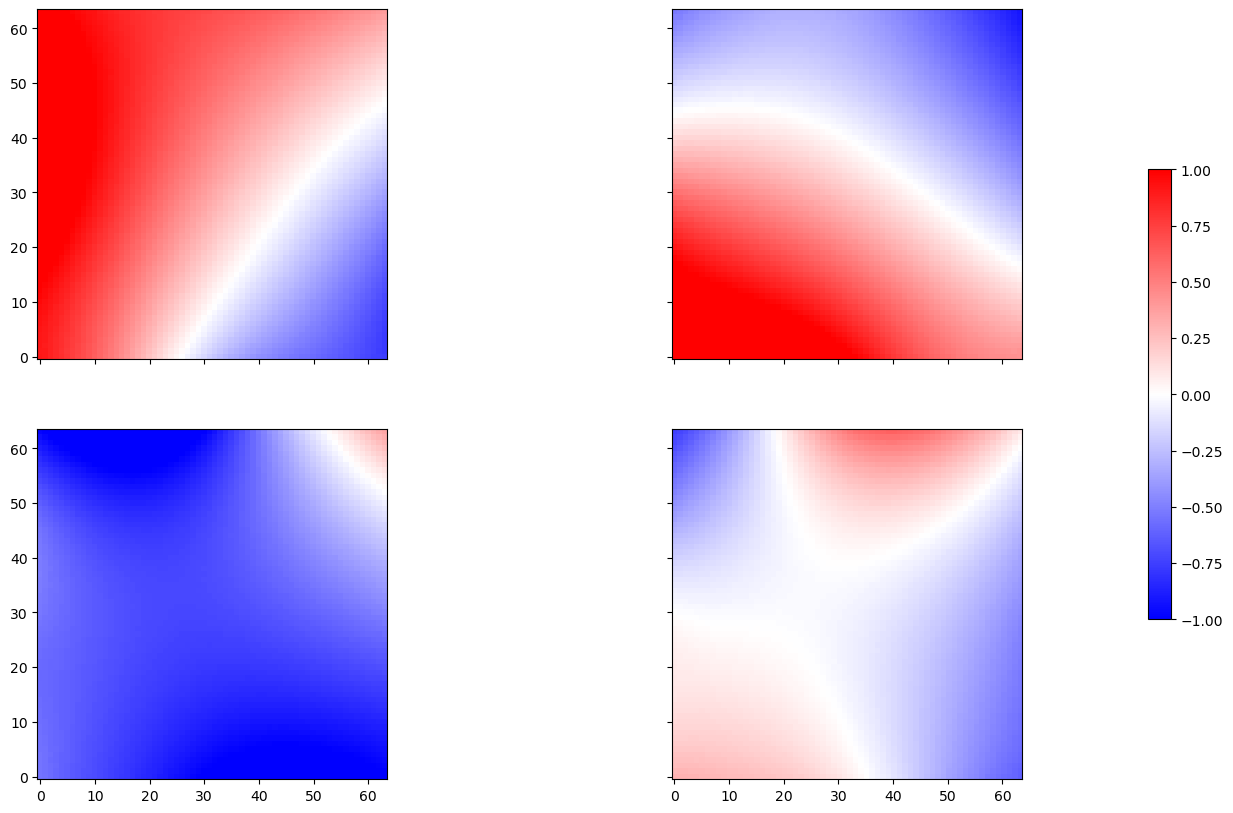

In [21]:
print(xh_unguided.detach().cpu()[0:2].shape)
fig = plot_ddpm_sample(xh_unguided.detach().cpu()[0:2])
curl_unguided = 0
div_unguided = 0
for sam in xh_unguided:
    sam = sam.detach().cpu()  # noqa: PLW2901
    curl_unguided += abs(curl_2d(sam)).mean()
    div_unguided += abs(div_2d(sam)).mean()
print(f"Avg Curl: {curl_unguided/100} | Avg Div: {div_unguided/100}")

Generating 100 samples...


  0%|          | 0/200 [00:00<?, ?step/s]

100%|██████████| 200/200 [00:10<00:00, 18.77step/s]


Generating 100 samples...


100%|██████████| 200/200 [00:10<00:00, 18.74step/s]


...

100%|██████████| 200/200 [00:10<00:00, 18.53step/s]


Generating 100 samples...


100%|██████████| 200/200 [00:10<00:00, 18.53step/s]


Generating 100 samples...


100%|██████████| 200/200 [00:10<00:00, 18.53step/s]


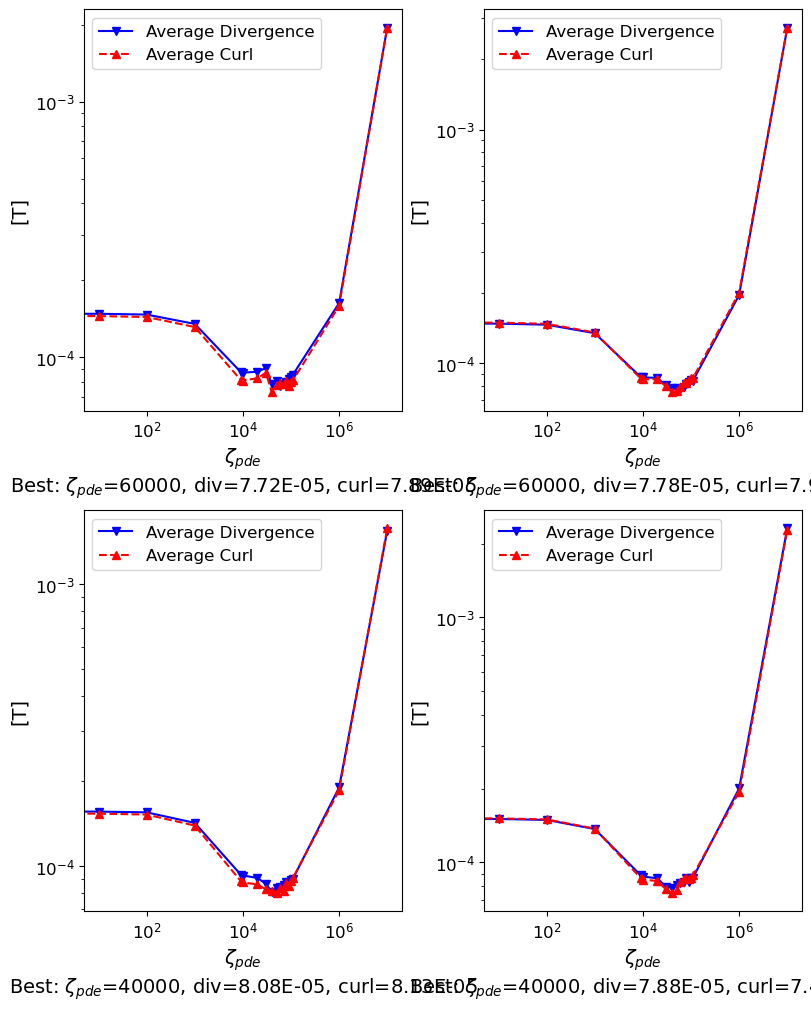

In [34]:
fig,axes = plt.subplots(2,2,layout="constrained", figsize=(8,10))
zetas = [0,10,100,1000,9000,10000,20000,30000,40000,50000,60000,70000,80000,90000,100000,110000,1000000,10000000]
    #zetas = [10,100,1000,10000,50000,100000,1000000,10000000,100000000]
for i in range(4):
    divs = []
    curls = []
    n_samples = 100
    latent_zeta_est = torch.randn(
                [n_samples, 2, 64, 64],
                device=device,
            )
    for zeta in zetas:
        xh_pde_sweep = sample(
                    ddpm_chosen,
                    n_samples,
                    device,
                    num_steps=200,
                    sigma=[0.002, 80],
                    rho=7,
                    pde_loss=True,
                    zeta_pde=zeta,
                    obs_scaling=scaling,
                    init_noise=latent_zeta_est
                ).detach().cpu()
        curl_pde = 0
        div_pde = 0
        for sam in xh_pde_sweep:
            curl_pde += np.abs(curl_2d(sam)).mean()
            div_pde += np.abs(div_2d(sam)).mean()
        divs.append(div_pde)
        curls.append(curl_pde)
        #print(f"For zeta_div = {zeta}, avg div = {div_pde/n_samples} & avg curl = {curl_pde/n_samples}")

    best_index = np.argmin(divs)
    ax = axes.flat[i]
    ax.plot(zetas,np.array(divs)/n_samples, "-vb", label="Average Divergence")
    ax.plot(zetas,np.array(curls)/n_samples, "--^r", label="Average Curl")
    ax.set_xticks([0,10,100,1000,10000,100000,1000000,10000000])
    ax.tick_params(labelsize=12)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(f"$\zeta_{{pde}}$\nBest: $\zeta_{{pde}}$={zetas[best_index]}, div={divs[best_index]/n_samples:.2E}, curl={curls[best_index]/n_samples:.2E}", fontsize=14)
    ax.set_ylabel("[T]", fontsize=14)
    ax.legend(fontsize=12)
    

In [39]:
fig.set_layout_engine("none")
fig.set_size_inches((10,10))
fig.savefig("test_4")

Generating 1 samples...


  8%|▊         | 17/200 [00:00<00:01, 163.80step/s]

100%|██████████| 200/200 [00:01<00:00, 154.50step/s]


Generating 1 samples...


100%|██████████| 200/200 [00:02<00:00, 84.74step/s] 


...

100%|██████████| 200/200 [00:02<00:00, 98.25step/s] 


Generating 1 samples...


100%|██████████| 200/200 [00:01<00:00, 101.13step/s]


Generating 1 samples...


100%|██████████| 200/200 [00:01<00:00, 109.16step/s]


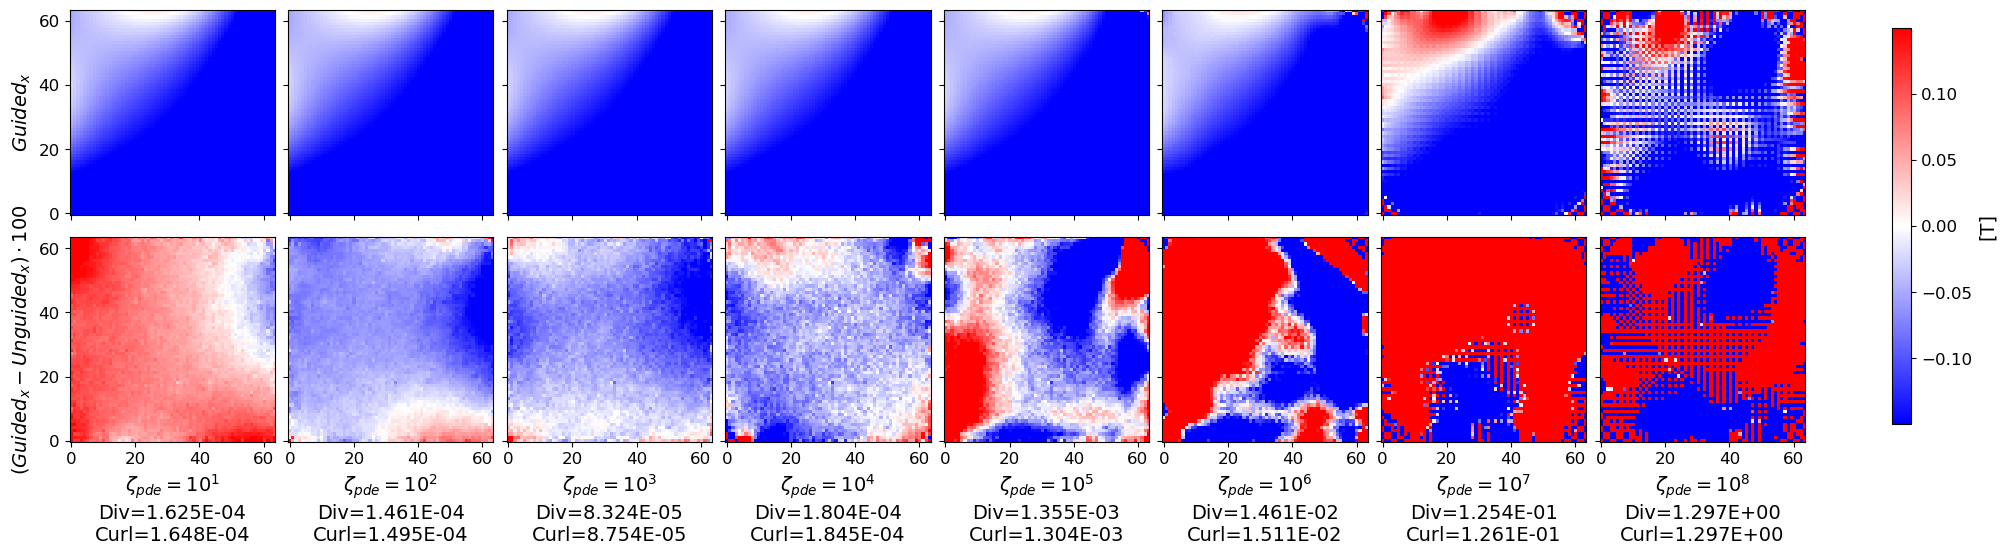

In [69]:
zeta_plot = [1,2,3,4,5,6,7,8]
latent_pde_match = torch.randn(
            [1, 2, 64, 64],
            device=device,
        )
unguided_pde_matched = sample(
                ddpm_chosen,
                1,
                device,
                num_steps=200,
                sigma=[0.002, 80],
                rho=7,
                pde_loss=False,
                obs_scaling=scaling,
                init_noise=latent_pde_match
            ).detach().cpu()
samples_pde_matched = []
for zeta in zeta_plot:
    xh_pde_matched = sample(
                ddpm_chosen,
                1,
                device,
                num_steps=200,
                sigma=[0.002, 80],
                rho=7,
                pde_loss=True,
                zeta_pde=10**zeta,
                obs_scaling=scaling,
                init_noise=latent_pde_match
            ).detach().cpu()
    samples_pde_matched.append(xh_pde_matched[0])
rows = 2
cols = len(zeta_plot)
fig, axes = plt.subplots(nrows=rows, ncols=cols, sharex=True, sharey=True, figsize=(20, 5.5), layout="constrained")
vmax=scaling
norm = colors.Normalize(vmin=-vmax, vmax=vmax)
for j, sam in enumerate(samples_pde_matched):
        ax1 = axes.flat[j]
        ax2 = axes.flat[j + cols]
        if j==0:
                ax1.set_ylabel("$Guided_x$", fontsize=14)
                ax2.set_ylabel("$(Guided_x-Unguided_x)\cdot 100$", fontsize=14)
        ax2.set_xlabel(f"$\zeta_{{pde}} = 10^{j+1}$\nDiv={np.abs(curl_2d(sam)).mean():.3E}\nCurl={np.abs(div_2d(sam)).mean():.3E}", fontsize = 14)
        ax1.tick_params(labelsize=12)
        ax2.tick_params(labelsize=12)
        im = ax1.imshow(sam[0], cmap="bwr", norm=norm, origin="lower")
        im = ax2.imshow((sam[0]-unguided_pde_matched[0,0,:,:])*100, cmap="bwr", norm=norm, origin="lower")
#cbar_ax = fig.add_axes([0.93, 0.12, 0.015, 0.75])
cbar1 = fig.colorbar(im, ax=axes, shrink=0.9) #cax=cbar_ax)
cbar1.ax.tick_params(labelsize=12)
cbar1.set_label("[T]", fontsize=14)
#fig.supxlabel("x [pixels]", fontsize=16)
#fig.supylabel("y [pixels]", fontsize=16)

In [12]:
div_test = 0
curl_test = 0
for field in fields["field"]:
    div_test += np.abs(curl_2d(field)).mean()
    curl_test += np.abs(div_2d(field)).mean()

print(div_test/30000)
print(curl_test/30000)

4.473341744062509e-06
4.468540828685263e-06


In [6]:
latent1 = torch.randn(
            [1, 2, 64, 64],
            device=device,
        )
latent2 = torch.randn(
            [1, 2, 64, 64],
            device=device,
        )

Generating 1 samples...


100%|██████████| 200/200 [00:02<00:00, 77.26step/s]


Generating 1 samples...


100%|██████████| 200/200 [00:03<00:00, 64.16step/s]


Generating 1 samples...


...

100%|██████████| 200/200 [00:02<00:00, 74.26step/s]


Generating 1 samples...


100%|██████████| 200/200 [00:02<00:00, 83.23step/s]


Generating 1 samples...


100%|██████████| 200/200 [00:02<00:00, 71.01step/s]


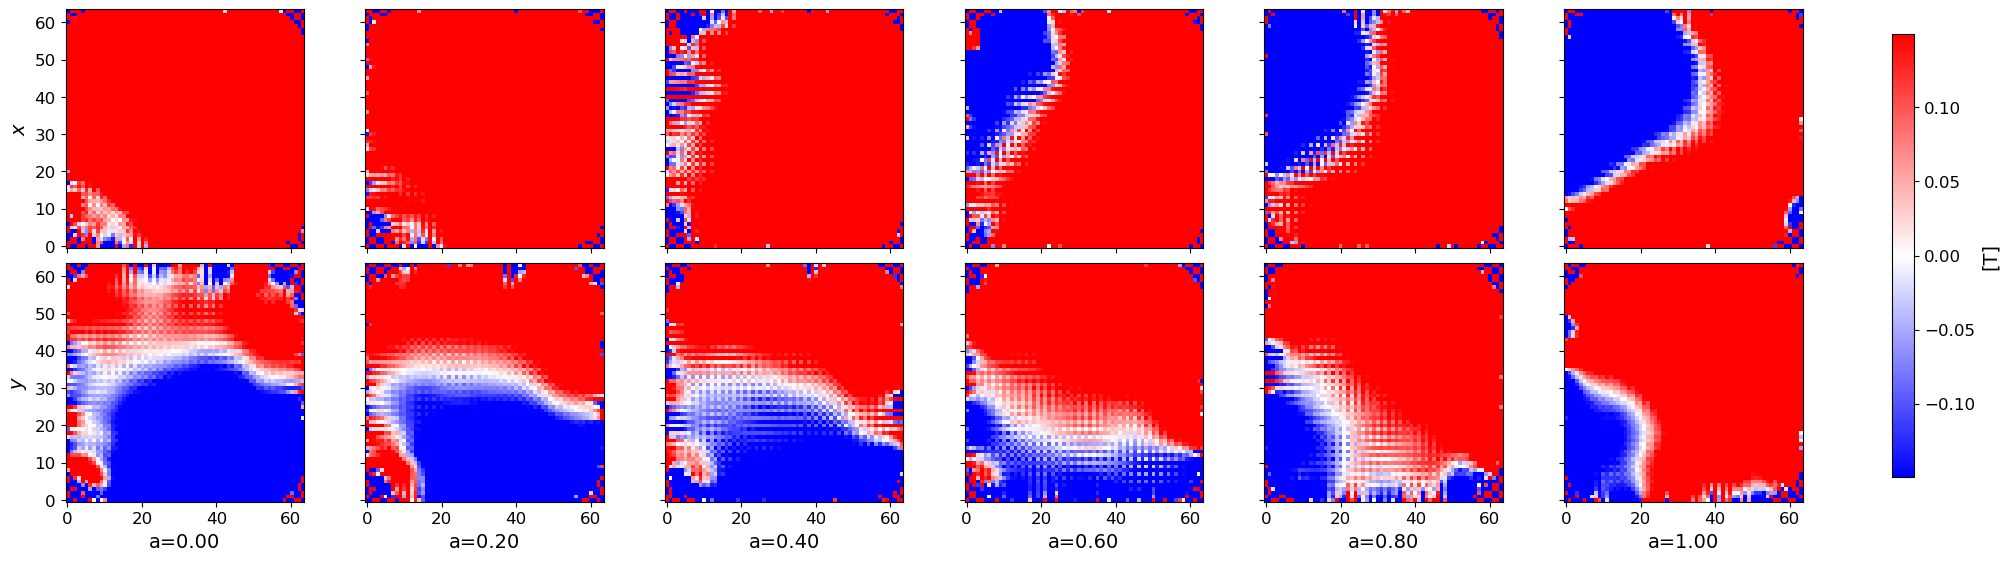

In [9]:
steps = 6
rows = 2
cols = steps
fig, axes = plt.subplots(nrows=rows, ncols=cols, sharex=True, sharey=True, figsize=(20, 5.5), layout="constrained")
vmax=scaling
norm = colors.Normalize(vmin=-vmax, vmax=vmax)

for i in range(steps):
    a = (i)/(steps-1)
    latent = latent1 +  a * (latent2 - latent1)
    xh_latent_walk = sample(
                ddpm_chosen,
                1,
                device,
                num_steps=200,
                sigma=[0.002, 80],
                rho=7,
                pde_loss=True,
                zeta_pde=1000000,
                init_noise=latent
            ).detach().cpu()
    ax1 = axes.flat[i]
    ax2 = axes.flat[i + cols]
    if i==0:
            ax1.set_ylabel("$x$", fontsize=14)
            ax2.set_ylabel("$y$", fontsize=14)
            ax2.set_xlabel("Ground Truth", fontsize = 14)
    ax2.set_xlabel(f"a={a:.2f}", fontsize = 14)
    ax1.tick_params(labelsize=12)
    ax2.tick_params(labelsize=12)
    im = ax1.imshow(xh_latent_walk[0,0], cmap="bwr", norm=norm, origin="lower")
    im = ax2.imshow(xh_latent_walk[0,1], cmap="bwr", norm=norm, origin="lower")
    fig.savefig(f"interpolation_unguided_{i}")

cbar1 = fig.colorbar(im, ax=axes, shrink=0.9) #cax=cbar_ax)
cbar1.ax.tick_params(labelsize=12)
cbar1.set_label("[T]", fontsize=14)
    

In [75]:
obs_matched_torch = torch.tensor(np.array(obs_load["field"])[0:1]).to(device)
latent_obs_match = torch.randn(
            [1, 2, 64, 64],
            device=device,
        )
n_points = 100
mask=torch.zeros([1,2,64,64], device=device)
indexX = np.random.randint(0, 64, n_points)
indexY = np.random.randint(0, 64, n_points)
for i in range(n_points):
    mask[:, :, indexX[i], indexY[i]] = 1

print(obs_matched_torch[0]*mask[0])

tensor([[[-0.0000, -0.0000, -0.0000,  ..., -0.0000, -0.0000, -0.0000],
         [-0.0000, -0.0000, -0.0000,  ..., -0.0000, -0.0000, -0.0000],
         [-0.0000, -0.0000, -0.0000,  ..., -0.0000, -0.0000, -0.0000],
         ...,
         [-0.0000, -0.0000, -0.0000,  ..., -0.0000, -0.0000, -0.0000],
         [-0.0000, -0.0000, -0.1687,  ..., -0.0000, -0.0000, -0.0000],
         [-0.0000, -0.0000, -0.0000,  ..., -0.0000, -0.0000, -0.0000]],

        [[-0.0000, -0.0000, -0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [-0.0000, -0.0000, -0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [-0.0000, -0.0000, -0.0000,  ...,  0.0000,  0.0000,  0.0000],
         ...,
         [-0.0000, -0.0000, -0.0000,  ..., -0.0000, -0.0000, -0.0000],
         [-0.0000, -0.0000, -0.1364,  ..., -0.0000, -0.0000, -0.0000],
         [-0.0000, -0.0000, -0.0000,  ..., -0.0000, -0.0000, -0.0000]]],
       device='cuda:1')


Generating 1 samples...


100%|██████████| 200/200 [00:03<00:00, 60.04step/s]


Generating 1 samples...


100%|██████████| 200/200 [00:03<00:00, 56.56step/s]


Generating 1 samples...


...

100%|██████████| 200/200 [00:03<00:00, 61.01step/s]


Generating 1 samples...


100%|██████████| 200/200 [00:02<00:00, 83.65step/s]


Generating 1 samples...


100%|██████████| 200/200 [00:02<00:00, 81.39step/s]


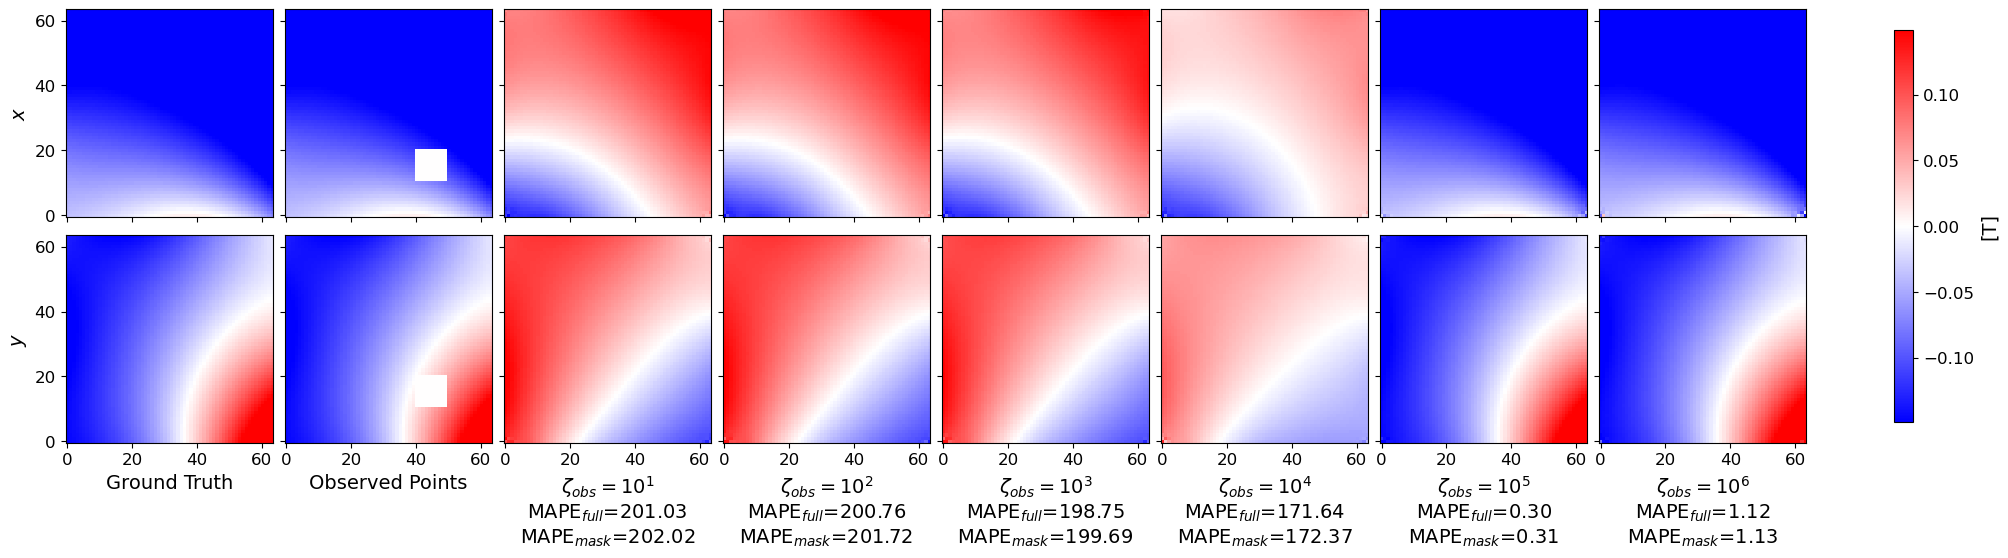

In [14]:
zeta_obs_plot = [1,2,3,4,5,6]
obs_matched_torch = torch.tensor(np.array(obs_load["field"])[0:1]).to(device)
latent_obs_match = torch.randn(
            [1, 2, 64, 64],
            device=device,
        )
#n_points = 100
#mask=torch.zeros([1,2,64,64], device=device)
# indexX = np.random.randint(0, 64, n_points)
# indexY = np.random.randint(0, 64, n_points)
# for i in range(n_points):
#     mask[:, :, indexX[i], indexY[i]] = 1

side_length = 10
mask=torch.ones([1,2,64,64], device=device)
indexX = np.random.randint(0, 64-side_length+1)
indexY = np.random.randint(0, 64-side_length+1)
for i in range(side_length):
      for j in range(side_length):
            mask[:,:,indexX+i,indexY+j] = 0

samples_obs_matched = []
samples_obs_matched.append(obs_matched_torch.detach().cpu()[0])
samples_obs_matched.append(obs_matched_torch.detach().cpu()[0]*mask.detach().cpu()[0])
for zeta in zeta_obs_plot:
    xh_obs_matched = sample(
                ddpm_chosen,
                1,
                device,
                num_steps=200,
                sigma=[0.002, 80],
                rho=7,
                pde_loss=True,
                zeta_pde=10000,
                obs_loss=True,
                observations=obs_matched_torch,
                zeta_obs=10**zeta,
                mask=mask,
                obs_scaling=scaling,
                init_noise=latent_obs_match
            ).detach().cpu()
    samples_obs_matched.append(xh_obs_matched[0])
rows = 2
cols = len(zeta_obs_plot)+2
fig, axes = plt.subplots(nrows=rows, ncols=cols, sharex=True, sharey=True, figsize=(20, 5.5), layout="constrained")
vmax=scaling
norm = colors.Normalize(vmin=-vmax, vmax=vmax)
for j, sam in enumerate(samples_obs_matched):
        ax1 = axes.flat[j]
        ax2 = axes.flat[j + cols]
        if j==0:
                ax1.set_ylabel("$x$", fontsize=14)
                ax2.set_ylabel("$y$", fontsize=14)
                ax2.set_xlabel("Ground Truth", fontsize = 14)
        elif j==1:
               ax2.set_xlabel("Observed Points", fontsize = 14)
        else:
            ax2.set_xlabel(f"$\zeta_{{obs}} = 10^{j-1}$\nMAPE$_{{full}}$={MAPE(gts=obs_matched_torch.detach().cpu(), preds=sam):.2f}\nMAPE$_{{mask}}$={MAPE(gts=obs_matched_torch.detach().cpu(), preds=sam, mask=mask.detach().cpu()):.2f}", fontsize = 14)
        ax1.tick_params(labelsize=12)
        ax2.tick_params(labelsize=12)
        im = ax1.imshow(sam[0], cmap="bwr", norm=norm, origin="lower")
        im = ax2.imshow(sam[1], cmap="bwr", norm=norm, origin="lower")
cbar1 = fig.colorbar(im, ax=axes, shrink=0.9) #cax=cbar_ax)
cbar1.ax.tick_params(labelsize=12)
cbar1.set_label("[T]", fontsize=14)

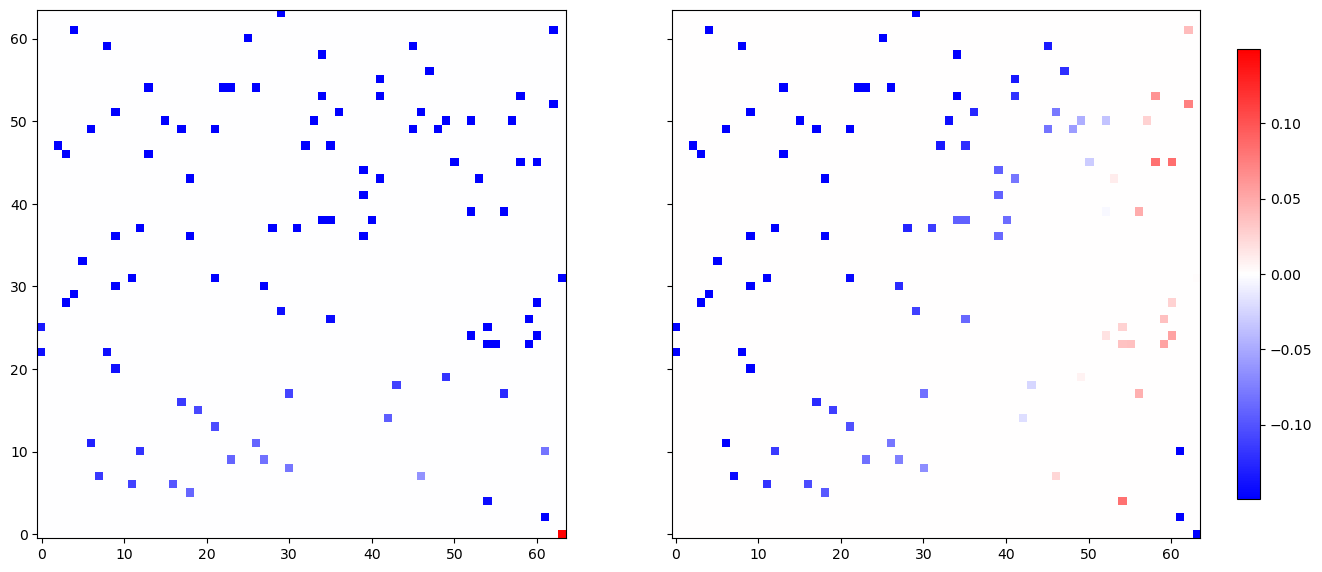

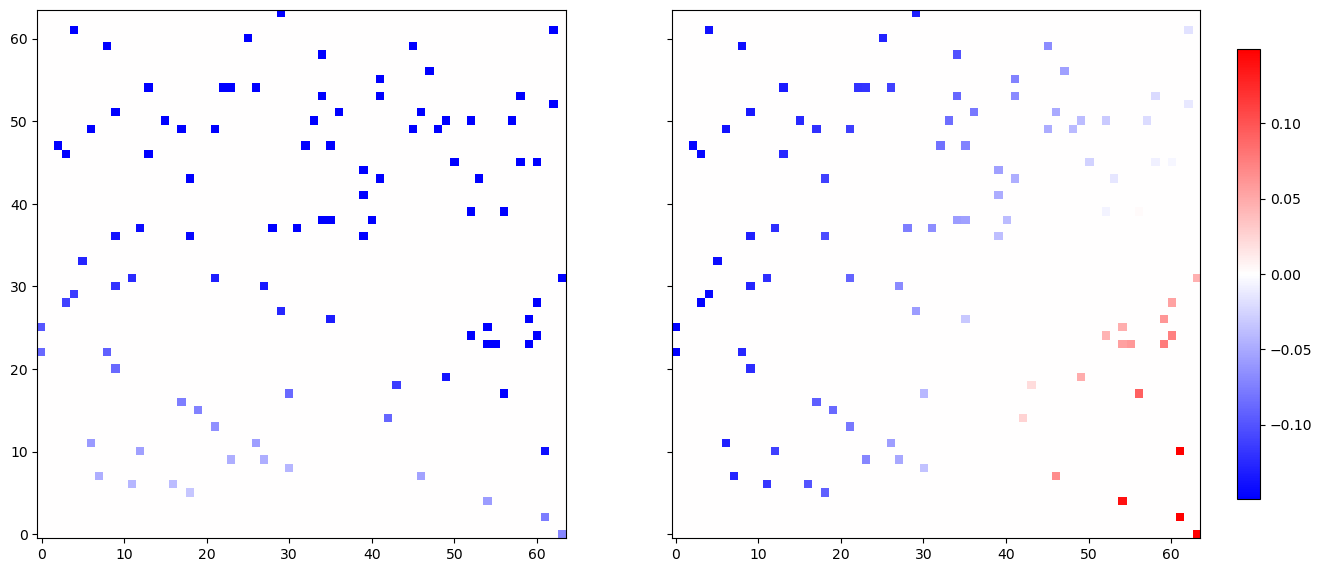

In [67]:
_ = plot_ddpm_sample(torch.unsqueeze(sam*mask.detach().cpu()[0], dim=0), vmax=scaling)
_ = plot_ddpm_sample(torch.unsqueeze(obs_matched_torch.detach().cpu()[0]*mask.detach().cpu()[0], dim=0), vmax=scaling)

In [41]:
for i in range(
    n_points_test = 100
    n_obs_test= 100
    data_index_test = np.random.randint(0, len(obs_load), n_points_test)
    obs_torch_test = torch.tensor(np.array(obs_load["field"])[0:n_obs_test]).to(device)
    mask_test=torch.zeros([1,2,64,64], device=device)
    indexX = np.random.randint(0, 64, n_points_test)
    indexY = np.random.randint(0, 64, n_points_test)
    for i in range(n_points_test):
        mask_test[:, :, indexX[i], indexY[i]] = 1
    xh_obs_test = sample(
                        ddpm_chosen,
                        n_obs_test,
                        device,
                        num_steps=200,
                        sigma=[0.002, 80],
                        rho=7,
                        pde_loss=True,
                        zeta_pde=10000,
                        obs_loss=True,
                        observations=obs_torch_test,
                        zeta_obs=100000000,
                        mask=mask_test,
                        obs_scaling=scaling
                    ).detach().cpu()

Generating 100 samples...


100%|██████████| 200/200 [00:15<00:00, 12.64step/s]


In [42]:
MAPE(obs_torch_test.detach().cpu(), xh_obs_test, mask_test.detach().cpu())
          

tensor(10.1987, dtype=torch.float64)

In [19]:
#torch.sum(/).sum(dim=(2,3)))

#print((torch.abs(obs_torch_test.detach().cpu()-xh_obs_test)*mask_test.detach().cpu()[0]).sum(dim=(2,3)))
#print(torch.abs(obs_torch_test.detach().cpu()*mask_test.detach().cpu()[0]).sum(dim=(2,3)))

torch.abs(((obs_torch_test.detach().cpu()-xh_obs_test)*mask_test.detach().cpu()[0])/(obs_torch_test.detach().cpu()*mask_test.detach().cpu()[0])).sum()

tensor(nan, dtype=torch.float64)

In [1]:
best_MAPE_mask_each = []
best_MAPE_full_each = []
best_ZETA_each = []
div_at_best = []
curl_at_best = []
#std_at_best = []
#point_amounts = [(n_temp+1)*10 for n_temp in range(100)]
point_amounts = [10,100,1000]
n_obs=100
latent_zeta_obs = torch.randn(
            [100, 2, 64, 64],
            device=device,
        )
obs_torch = torch.tensor(np.array(obs_load["field"])[0:n_obs]).to(device)

for n_points in point_amounts:
    #zeta_obs = [10000,100000,1000000,10000000]
    zeta_obs = [0,10,100,1000,9000,10000,20000,30000,40000,50000,60000,70000,80000,90000,100000,110000,200000,300000,400000,500000,600000,700000,800000,900000,1000000, 11000000,10000000]
    mask=torch.zeros([1,2,64,64], device=device)
    indexX = np.random.randint(0, 64, n_points)
    indexY = np.random.randint(0, 64, n_points)
    for i in range(n_points):
        mask[:, :, indexX[i], indexY[i]] = 1

    # side_length = 10
    # mask=torch.ones([1,2,64,64], device=device)
    # indexX = np.random.randint(0, 64-side_length+1)
    # indexY = np.random.randint(0, 64-side_length+1)
    # for i in range(side_length):
    #   for j in range(side_length):
    #         mask[:,:,indexX+i,indexY+j] = 0

    mape_full = []
    mape_mask = []
    divs_obs = []
    curls_obs = []

    obs_detached = obs_torch.detach().cpu()
    mask_detached = mask.detach().cpu()

    for zeta in zeta_obs:
        xh_obs_sweep = sample(
                    ddpm_chosen,
                    n_obs,
                    device,
                    num_steps=200,
                    sigma=[0.002, 80],
                    rho=7,
                    pde_loss=True,
                    zeta_pde=10000,
                    obs_loss=True,
                    observations=obs_torch,
                    zeta_obs=zeta,
                    mask=mask,
                    obs_scaling=scaling
                ).detach().cpu()
        curl = 0
        div = 0
        for sam in xh_obs_sweep:
            curl += np.abs(curl_2d(sam)).mean()
            div += np.abs(div_2d(sam)).mean()
        divs_obs.append(div/n_obs)
        curls_obs.append(curl/n_obs)
        mape_full.append(MAPE(gts=obs_detached, preds=xh_obs_sweep))
        mape_mask.append(MAPE(gts=obs_detached, preds=xh_obs_sweep, mask=mask_detached))

    # fig,ax = plt.subplots(ncols=2, nrows=1, layout="constrained")
    # ax1 = ax.flat[0]
    # #fig,ax1 = plt.subplots()
    # ax1.plot(zeta_obs,np.array(divs_obs), "-vb", label="Div")
    # ax1.plot(zeta_obs,np.array(curls_obs), "--^r", label="Curl")
    # ax1.set_xticks([1,10,100,1000,10000,100000,1000000,10000000])
    # ax1.tick_params(labelsize=12)
    # ax1.set_xscale("log")
    # ax1.set_yscale("log")
    # ax1.set_xlabel("$\zeta_{obs}$", fontsize=14)
    # ax1.set_ylabel("[T]", fontsize=14)
    # ax1.legend(fontsize=12, loc="upper left")

    # ax2 = ax.flat[1]
    # #ax2 = ax1.twinx()
    # ax2.plot(zeta_obs,np.array(mape_full), "-vb", label="Full")
    # ax2.plot(zeta_obs,np.array(mape_mask), "--^r", label="Mask")
    # ax2.set_xticks([1,10,100,1000,10000,100000,1000000,10000000])
    # ax2.tick_params(labelsize=12)
    # ax2.set_xscale("log")
    # ax2.set_yscale("log")
    # ax2.set_xlabel("$\zeta_{obs}$", fontsize=14)
    # ax2.set_ylabel("MAPE [%]", fontsize=14)
    # ax2.legend(fontsize=12, loc="upper right")

    best_MAPE_mask_each.append(np.min(mape_mask))
    best_index = np.argmin(mape_mask)
    best_MAPE_full_each.append(mape_full[best_index])
    best_ZETA_each.append(zeta_obs[best_index])
    div_at_best.append(divs_obs[best_index])
    curl_at_best.append(curls_obs[best_index])

    fig.savefig(fname=f"zeta_obs_points_{n_points}_noise_controlled")
    #print(f"Best MAPE for {n_points} points was {best_MAPE_mask_each[-1]}, at zeta={best_ZETA_each[-1]}")

NameError: name 'torch' is not defined

In [ ]:
fig, ax1 = plt.subplots()
ax1.plot(point_amounts, best_MAPE_full_each, "-b", label="Full")
ax1.plot(point_amounts, best_MAPE_mask_each, "-c", label="Masked")
ax1.set_yscale("log")
ax1.set_ylabel("MAPE [%]", fontsize=14)
ax1.set_xlabel("Points", fontsize = 14)
ax1.legend(fontsize=12, loc="upper left")

ax2=ax1.twinx()
ax2.plot(point_amounts, div_at_best, "tab:red", label="Div")
ax2.plot(point_amounts, curl_at_best, "tab:orange", label="Curl")
ax2.set_yscale("log")
ax2.set_ylabel("[T]", fontsize=14)
ax2.legend(fontsize=12, loc="upper right")

In [49]:
print(point_amounts)
print(best_ZETA_each)
print(best_MAPE_mask_each)
print(best_MAPE_full_each)
print(div_at_best)
print(curl_at_best)


[10, 100, 620, 1000]
[600000, 600000, 600000, 800000]
[0.19294881866193936, 0.19856476476623697, 0.1955585821744924, 0.19904135456591024]
[tensor(0.1986, dtype=torch.float64), tensor(0.2005, dtype=torch.float64), tensor(0.2001, dtype=torch.float64), tensor(0.2032, dtype=torch.float64)]
[3.804816007488008e-05, 3.698364785526197e-05, 3.801779976561731e-05, 3.677513802723236e-05]
[3.7530572807515445e-05, 3.649702490651701e-05, 3.716120806115121e-05, 3.605922087956435e-05]


Generating 100 samples...


100%|██████████| 200/200 [00:15<00:00, 12.64step/s]


[tensor(37.1664, dtype=torch.float64), tensor(10.5111, dtype=torch.float64), tensor(30.9792, dtype=torch.float64), tensor(30.0681, dtype=torch.float64), tensor(34.1505, dtype=torch.float64), tensor(23.4552, dtype=torch.float64), tensor(45.2517, dtype=torch.float64), tensor(32.7797, dtype=torch.float64), tensor(25.4612, dtype=torch.float64), tensor(23.5413, dtype=torch.float64), tensor(27.9302, dtype=torch.float64), tensor(8.3827, dtype=torch.float64), tensor(25.4986, dtype=torch.float64), tensor(23.6988, dtype=torch.float64), tensor(43.1494, dtype=torch.float64), tensor(33.0059, dtype=torch.float64), tensor(30.8243, dtype=torch.float64), tensor(21.4193, dtype=torch.float64), tensor(31.4928, dtype=torch.float64), tensor(29.3664, dtype=torch.float64), tensor(21.5690, dtype=torch.float64), tensor(28.1140, dtype=torch.float64), tensor(2423.3131, dtype=torch.float64), tensor(39.7528, dtype=torch.float64), tensor(27.0642, dtype=torch.float64), tensor(26.7263, dtype=torch.float64), tensor(24.

100%|██████████| 200/200 [00:15<00:00, 12.63step/s]


[tensor(0.9737, dtype=torch.float64), tensor(1.5372, dtype=torch.float64), tensor(0.8147, dtype=torch.float64), tensor(0.8953, dtype=torch.float64), tensor(2.1241, dtype=torch.float64), tensor(1.8739, dtype=torch.float64), tensor(0.7981, dtype=torch.float64), tensor(1.4636, dtype=torch.float64), tensor(0.9330, dtype=torch.float64), tensor(1.0757, dtype=torch.float64), tensor(2.3874, dtype=torch.float64), tensor(1.3854, dtype=torch.float64), tensor(1.2696, dtype=torch.float64), tensor(1.0673, dtype=torch.float64), tensor(3.5788, dtype=torch.float64), tensor(1.8203, dtype=torch.float64), tensor(1.0727, dtype=torch.float64), tensor(1.4461, dtype=torch.float64), tensor(1.2579, dtype=torch.float64), tensor(1.3235, dtype=torch.float64), tensor(2.2464, dtype=torch.float64), tensor(1.0859, dtype=torch.float64), tensor(1.0323, dtype=torch.float64), tensor(1.0948, dtype=torch.float64), tensor(1.1365, dtype=torch.float64), tensor(0.9217, dtype=torch.float64), tensor(1.4654, dtype=torch.float64), 

100%|██████████| 200/200 [00:15<00:00, 12.61step/s]


[tensor(0.4732, dtype=torch.float64), tensor(0.5633, dtype=torch.float64), tensor(0.6244, dtype=torch.float64), tensor(0.5088, dtype=torch.float64), tensor(0.4380, dtype=torch.float64), tensor(0.4535, dtype=torch.float64), tensor(0.4751, dtype=torch.float64), tensor(0.4834, dtype=torch.float64), tensor(0.3674, dtype=torch.float64), tensor(0.6109, dtype=torch.float64), tensor(0.4722, dtype=torch.float64), tensor(0.3970, dtype=torch.float64), tensor(0.4892, dtype=torch.float64), tensor(0.5470, dtype=torch.float64), tensor(0.4318, dtype=torch.float64), tensor(0.3294, dtype=torch.float64), tensor(0.5793, dtype=torch.float64), tensor(0.4666, dtype=torch.float64), tensor(0.4210, dtype=torch.float64), tensor(0.4227, dtype=torch.float64), tensor(0.5250, dtype=torch.float64), tensor(0.3642, dtype=torch.float64), tensor(0.3702, dtype=torch.float64), tensor(0.5699, dtype=torch.float64), tensor(0.3206, dtype=torch.float64), tensor(0.4180, dtype=torch.float64), tensor(0.5373, dtype=torch.float64), 

100%|██████████| 200/200 [00:15<00:00, 12.59step/s]


[tensor(0.2626, dtype=torch.float64), tensor(0.3776, dtype=torch.float64), tensor(0.3568, dtype=torch.float64), tensor(0.3012, dtype=torch.float64), tensor(0.3078, dtype=torch.float64), tensor(0.3754, dtype=torch.float64), tensor(0.3620, dtype=torch.float64), tensor(0.4386, dtype=torch.float64), tensor(0.2735, dtype=torch.float64), tensor(0.4279, dtype=torch.float64), tensor(0.3529, dtype=torch.float64), tensor(0.3107, dtype=torch.float64), tensor(0.4811, dtype=torch.float64), tensor(0.3606, dtype=torch.float64), tensor(0.3837, dtype=torch.float64), tensor(0.4030, dtype=torch.float64), tensor(0.3896, dtype=torch.float64), tensor(0.4424, dtype=torch.float64), tensor(0.3610, dtype=torch.float64), tensor(0.3878, dtype=torch.float64), tensor(0.3994, dtype=torch.float64), tensor(0.2540, dtype=torch.float64), tensor(0.3818, dtype=torch.float64), tensor(0.3149, dtype=torch.float64), tensor(0.3110, dtype=torch.float64), tensor(0.4520, dtype=torch.float64), tensor(0.3941, dtype=torch.float64), 

IndexError: list index out of range

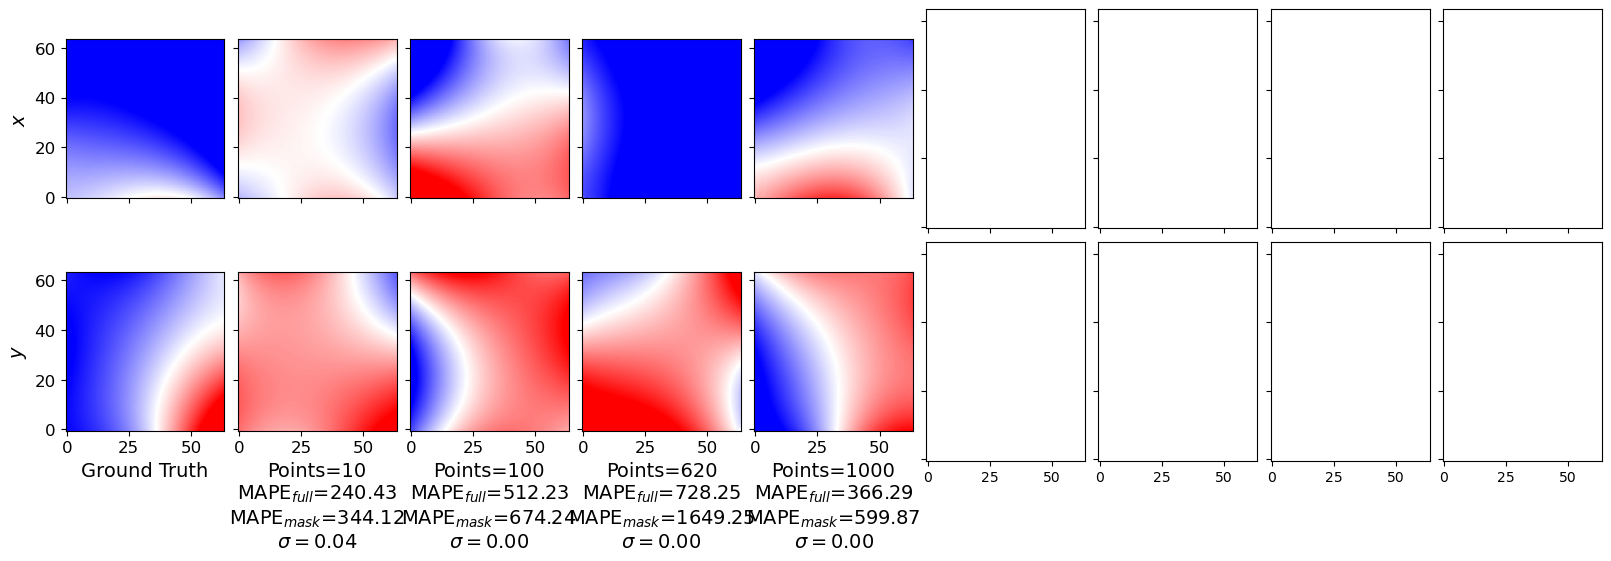

In [48]:
n_obs_std = 100
obs_torch_std = torch.tensor(np.array(obs_load["field"])[0:1]).to(device)
samples_obs_std = []
samples_obs_std.append(obs_torch_std.detach().cpu()[0])
mapes_full = []
mapes_mask = []
mapes_full_std = []
mapes_mask_std = []
mapes_full_avg = []
mapes_mask_avg = []
mapes_plotting = []

for j in range(len(point_amounts)):
        mask=torch.zeros([1,2,64,64], device=device)
        indexX = np.random.randint(0, 64, point_amounts[j])
        indexY = np.random.randint(0, 64, point_amounts[j])
        for i in range(point_amounts[j]):
                mask[:, :, indexX[i], indexY[i]] = 1
        xh_obs_sweep_std = sample(
                        ddpm_chosen,
                        n_obs_std,
                        device,
                        num_steps=200,
                        sigma=[0.002, 80],
                        rho=7,
                        pde_loss=True,
                        zeta_pde=10000,
                        obs_loss=True,
                        observations=obs_torch_std,
                        zeta_obs=best_ZETA_each[j],
                        mask=mask,
                        obs_scaling=scaling
                        ).detach().cpu()
        #print(xh_obs_sweep_std)
        #print(xh_obs_sweep_std.shape)
        #print(samples_obs_std)
        mapes_full.append(MAPE(gts=obs_torch_std.detach().cpu(), preds=xh_obs_sweep_std[0]))
        mapes_mask.append(MAPE(gts=obs_torch_std.detach().cpu(), preds=xh_obs_sweep_std[0], mask=mask.detach().cpu()))

        mape_full_calc = []
        mape_mask_calc = []
        for sam in xh_obs_sweep_std:
                mape_full_calc.append(MAPE(gts=obs_torch_std.detach().cpu(), preds=sam))
                mape_mask_calc.append(MAPE(gts=obs_torch_std.detach().cpu(), preds=sam, mask=mask.detach().cpu()))
        
        print(mape_full_calc)
        print(mape_mask_calc)
        index_best = np.argmax(mape_full_calc)
        index_worst = np.argmin(mape_full_calc)
        mapes_full_std.append(np.std(mape_full_calc))
        mapes_mask_std.append(np.std(mape_mask_calc))
        mapes_full_avg.append(np.mean(mape_full_calc))
        mapes_mask_avg.append(np.mean(mape_mask_calc))
        samples_obs_std.append(xh_obs_sweep[index_worst])
        samples_obs_std.append(xh_obs_sweep[index_best])
        

rows = 2
cols = len(point_amounts)*2+1
fig, axes = plt.subplots(nrows=rows, ncols=cols, sharex=True, sharey=True, figsize=(16, 5.5), layout="constrained")
vmax=scaling
norm = colors.Normalize(vmin=-vmax, vmax=vmax)
for j, sam in enumerate(samples_obs_std):
        ax1 = axes.flat[j]
        ax2 = axes.flat[j + cols]
        if j==0:
                ax1.set_ylabel("$x$", fontsize=14)
                ax2.set_ylabel("$y$", fontsize=14)
                ax2.set_xlabel("Ground Truth", fontsize = 14)
        else:
                ax2.set_xlabel(f"Points={point_amounts[j-1]}\nMAPE$_{{full}}$={MAPE(gts=obs_torch_std.detach().cpu(), preds=sam):.2f}\nMAPE$_{{mask}}$={MAPE(gts=obs_torch_std.detach().cpu(), preds=sam, mask=mask.detach().cpu()):.2f}\n$\sigma=${stds[j-1]:.2f}", fontsize = 14)
        ax1.tick_params(labelsize=12)
        ax2.tick_params(labelsize=12)
        im = ax1.imshow(sam[0], cmap="bwr", norm=norm, origin="lower")
        im = ax2.imshow(sam[1], cmap="bwr", norm=norm, origin="lower")
cbar1 = fig.colorbar(im, ax=axes, shrink=0.9) #cax=cbar_ax)
cbar1.ax.tick_params(labelsize=12)
cbar1.set_label("[T]", fontsize=14)

print(mapes_full_avg)
print(mapes_full_std)
print(mapes_mask_avg)
print(mapes_mask_std)

In [ ]:
best_MAPE_mask_each = []
best_MAPE_full_each = []
best_ZETA_each = []
div_at_best = []
curl_at_best = []
#std_at_best = []
#point_amounts = [(n_temp+1)*10 for n_temp in range(100)]
point_amounts = [10,100,620,1000]

for n_points in point_amounts:
    n_obs=100
    #zeta_obs = [10000,100000,1000000,10000000]
    zeta_obs = [0,10,100,1000,9000,10000,20000,30000,40000,50000,60000,70000,80000,90000,100000,110000,200000,300000,400000,500000,600000,700000,800000,900000,1000000, 11000000,10000000]
    obs_torch = torch.tensor(np.array(obs_load["field"])[0:n_obs]).to(device)
    # mask=torch.zeros([1,2,64,64], device=device)
    # indexX = np.random.randint(0, 64, n_points)
    # indexY = np.random.randint(0, 64, n_points)
    # for i in range(n_points):
    #     mask[:, :, indexX[i], indexY[i]] = 1

    side_length = 10
    mask=torch.ones([1,2,64,64], device=device)
    indexX = np.random.randint(0, 64-side_length+1)
    indexY = np.random.randint(0, 64-side_length+1)
    for i in range(side_length):
      for j in range(side_length):
            mask[:,:,indexX+i,indexY+j] = 0

    mape_full = []
    mape_mask = []
    divs_obs = []
    curls_obs = []

    obs_detached = obs_torch.detach().cpu()
    mask_detached = mask.detach().cpu()

    for zeta in zeta_obs:
        xh_obs_sweep = sample(
                    ddpm_chosen,
                    n_obs,
                    device,
                    num_steps=200,
                    sigma=[0.002, 80],
                    rho=7,
                    pde_loss=True,
                    zeta_pde=10000,
                    obs_loss=True,
                    observations=obs_torch,
                    zeta_obs=zeta,
                    mask=mask,
                    obs_scaling=scaling
                ).detach().cpu()
        curl = 0
        div = 0
        for sam in xh_obs_sweep:
            curl += np.abs(curl_2d(sam)).mean()
            div += np.abs(div_2d(sam)).mean()
        divs_obs.append(div/n_obs)
        curls_obs.append(curl/n_obs)
        mape_full.append(MAPE(gts=obs_detached, preds=xh_obs_sweep))
        mape_mask.append(MAPE(gts=obs_detached, preds=xh_obs_sweep, mask=mask_detached))

    # fig,ax = plt.subplots(ncols=2, nrows=1, layout="constrained")
    # ax1 = ax.flat[0]
    # #fig,ax1 = plt.subplots()
    # ax1.plot(zeta_obs,np.array(divs_obs), "-vb", label="Div")
    # ax1.plot(zeta_obs,np.array(curls_obs), "--^r", label="Curl")
    # ax1.set_xticks([1,10,100,1000,10000,100000,1000000,10000000])
    # ax1.tick_params(labelsize=12)
    # ax1.set_xscale("log")
    # ax1.set_yscale("log")
    # ax1.set_xlabel("$\zeta_{obs}$", fontsize=14)
    # ax1.set_ylabel("[T]", fontsize=14)
    # ax1.legend(fontsize=12, loc="upper left")

    # ax2 = ax.flat[1]
    # #ax2 = ax1.twinx()
    # ax2.plot(zeta_obs,np.array(mape_full), "-vb", label="Full")
    # ax2.plot(zeta_obs,np.array(mape_mask), "--^r", label="Mask")
    # ax2.set_xticks([1,10,100,1000,10000,100000,1000000,10000000])
    # ax2.tick_params(labelsize=12)
    # ax2.set_xscale("log")
    # ax2.set_yscale("log")
    # ax2.set_xlabel("$\zeta_{obs}$", fontsize=14)
    # ax2.set_ylabel("MAPE [%]", fontsize=14)
    # ax2.legend(fontsize=12, loc="upper right")

    best_MAPE_mask_each.append(np.min(mape_mask))
    best_index = np.argmin(mape_mask)
    best_MAPE_full_each.append(mape_full[best_index])
    best_ZETA_each.append(zeta_obs[best_index])
    div_at_best.append(divs_obs[best_index])
    curl_at_best.append(curls_obs[best_index])

    #fig.savefig(fname=f"zeta_obs_points_{n_points}")
    print(f"Best MAPE for {n_points} points was {best_MAPE_mask_each[-1]}, at zeta={best_ZETA_each[-1]}")